<a href="https://colab.research.google.com/github/abyansyah052/softcomp-fuzz-ann/blob/master/BCANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
import zipfile
import os

bc_zip = '/content/Breast Cancer Wisconsin Diagnostic.zip'
with zipfile.ZipFile(bc_zip, 'r') as z:
    print(z.namelist())

# ekstrak
with zipfile.ZipFile(bc_zip, 'r') as z:
    z.extractall('/content/')

['wdbc.data', 'wdbc.names']


In [ ]:
cols = ['id','diagnosis'] + [f'f{i}' for i in range(1,31)]
df = pd.read_csv('/content/wdbc.data', names=cols)
df.drop('id', axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})
df.head()

,diagnosis,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

rf = RandomForestClassifier(n_estimators=100, random_state=42)

start = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start

start = time.time()
rf_pred = rf.predict(X_test)
rf_infer_time = time.time() - start

rf_acc = accuracy_score(y_test, rf_pred)
print(f"Accuracy : {rf_acc*100:.2f}%")
print(f"Runtime  : {rf_train_time + rf_infer_time:.4f}s")

Accuracy : 97.37%
Runtime  : 0.4344s


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(30,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

start = time.time()
history = model.fit(X_train, y_train, epochs=200, batch_size=16,
                    validation_split=0.2, callbacks=[early_stop], verbose=0)
mlp_train_time = time.time() - start

start = time.time()
mlp_prob = model.predict(X_test, verbose=0).flatten()
mlp_pred = (mlp_prob >= 0.5).astype(int)
mlp_infer_time = time.time() - start

mlp_acc = accuracy_score(y_test, mlp_pred)
print(f"Accuracy : {mlp_acc*100:.2f}%")
print(f"Runtime  : {mlp_train_time + mlp_infer_time:.4f}s")


Accuracy : 98.25%
Runtime  : 6.2315s


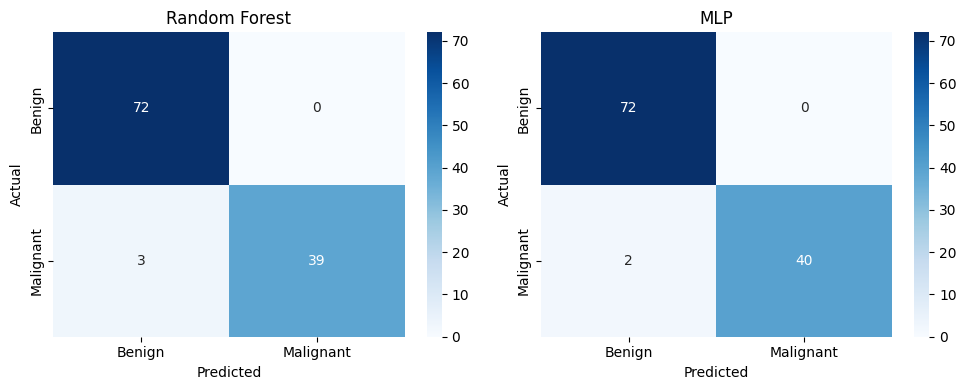

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, pred, title in zip(axes, [rf_pred, mlp_pred], ['Random Forest', 'MLP']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign','Malignant'],
                yticklabels=['Benign','Malignant'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


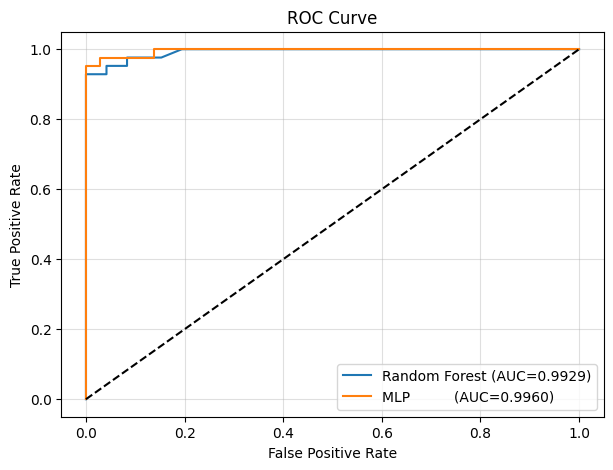

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

rf_prob  = rf.predict_proba(X_test)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_prob)
mlp_auc  = roc_auc_score(y_test, mlp_prob)

fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_prob)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC={rf_auc:.4f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP          (AUC={mlp_auc:.4f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.4)
plt.show()


In [ ]:
rf_runtime  = rf_train_time  + rf_infer_time
mlp_runtime = mlp_train_time + mlp_infer_time

summary = pd.DataFrame({
    'Model'   : ['Random Forest', 'MLP'],
    'Accuracy': [f'{rf_acc*100:.2f}%', f'{mlp_acc*100:.2f}%'],
    'AUC-ROC' : [f'{rf_auc:.4f}', f'{mlp_auc:.4f}'],
    'Runtime' : [f'{rf_runtime:.4f}s', f'{mlp_runtime:.4f}s']
})

print(summary.to_string(index=False))


        Model Accuracy AUC-ROC Runtime
Random Forest   97.37%  0.9929 0.2911s
          MLP   98.25%  0.9960 6.2315s
